# Assignment 2: Data Insights

Now that we know how to clean data, we will learn how to extract meaningful insights from it. For example, finding the average product rating and understanding what percentage of users gave a poor rating.

In [1]:
import json

with open('assignment2_data.json', 'r') as f:
    data = json.load(f)


## Extracting Insights

We will loop through the data, calculate the sum of all ratings, count how many ratings are 'poor' (<= 2), and then print our final statistics.

In [2]:
def get_insights(data):
    tot_rating = 0
    poor_rating = 0
    count = 0
    
    for user in data:
        if 'rating' in user:
            rating = int(user['rating'])
            tot_rating += rating
            count += 1
            if rating <= 2:
                poor_rating += 1
                
    if count > 0:
        print(f'Average rating = {tot_rating / count:.2f}')
        print(f'Percentage of poor ratings = {(poor_rating / count) * 100:.2f}%')
    else:
        print('No ratings found in data')

get_insights(data)

Average rating = 3.33
Percentage of poor ratings = 33.33%


## 3. Visualizing the Insights

Let's plot the ratio of 'Poor' vs 'Good' ratings based on our insights!

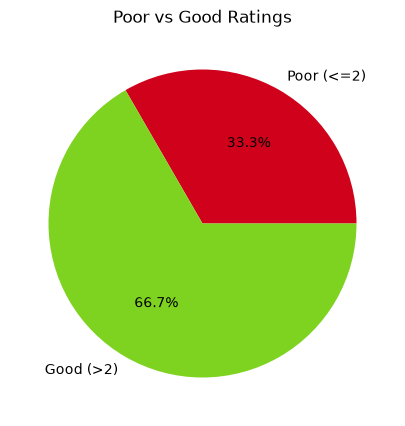

In [3]:
import matplotlib.pyplot as plt

# We know the logic from the insights function: ratings <= 2 are poor.
ratings = [float(user['rating']) for user in data if 'rating' in user]
poor_count = sum(1 for r in ratings if r <= 2)
good_count = len(ratings) - poor_count

plt.figure(figsize=(5, 5))
plt.pie([poor_count, good_count], labels=['Poor (<=2)', 'Good (>2)'], autopct='%1.1f%%', colors=['#D0021B', '#7ED321'])
plt.title('Poor vs Good Ratings')
plt.show()
